В качестве пользовательского идентификатора используется customer_unique_id, так как customer_id является позаказным идентификатором. Для расчета retention учитываются только заказы со статусом delivered, так как они отражают завершенную покупку и реальное взаимодействие пользователя с продуктом.

Статусы заказов:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
Месячный retention:
cohort_index   0         1         2         3         4         5         6   \
cohort_month                                                                    
2016-09       1.0       NaN       NaN       NaN       NaN       NaN       NaN   
2016-10       1.0       NaN       NaN       NaN       NaN       NaN  0.003817   
2016-12       1.0  1.000000       NaN       NaN       NaN       NaN       NaN   
2017-01       1.0  0.002789  0.002789  0.001395  0.004184  0.001395  0.004184   
2017-02       1.0  0.001843  0.003071  0.001229  0.004300  0.001229  0.002457   
2017-03       1.0  0.004395  0.003596  0.003995  0.003596  0.001598  0.001598   
2017-04       1.0  0.006206  0.002216  0.001773  0.002660  0.002660  0.003546   
2017-05       1.0  0.004636

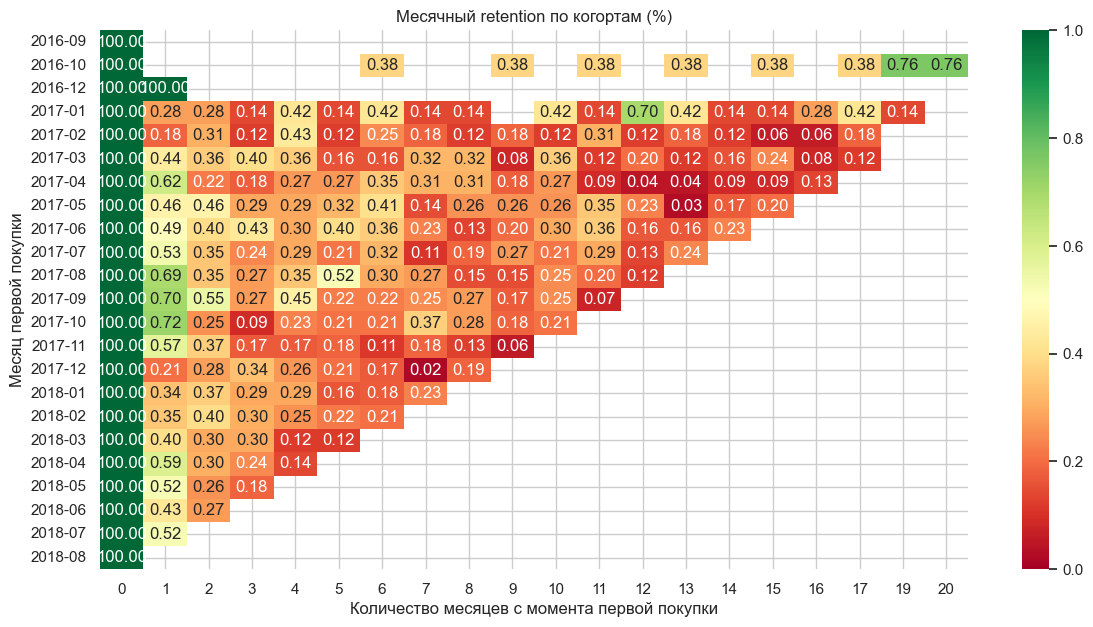

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv('data/olist_customers_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')

print('Статусы заказов:')
print(orders['order_status'].value_counts())

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

df = orders.merge(customers, on='customer_id', how='left')

# Для retention берем только доставленные заказы, так как они отражают завершенную покупку
df = df[df['order_status'] == 'delivered'].copy()

# В качестве пользователя используем customer_unique_id, так как customer_id является позаказным идентификатором
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

first_order = (
    df.groupby('customer_unique_id')['order_month']
    .min()
    .reset_index()
    .rename(columns={'order_month': 'cohort_month'})
)

df = df.merge(first_order, on='customer_unique_id', how='left')

df['cohort_index'] = (
    (df['order_month'].dt.year - df['cohort_month'].dt.year) * 12
    + (df['order_month'].dt.month - df['cohort_month'].dt.month)
)

cohort_data = (
    df.groupby(['cohort_month', 'cohort_index'])['customer_unique_id']
    .nunique()
    .reset_index()
)

cohort_size = (
    cohort_data[cohort_data['cohort_index'] == 0]
    [['cohort_month', 'customer_unique_id']]
    .rename(columns={'customer_unique_id': 'cohort_size'})
)

cohort_data = cohort_data.merge(cohort_size, on='cohort_month', how='left')
cohort_data['retention'] = cohort_data['customer_unique_id'] / cohort_data['cohort_size']

retention_table = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='retention'
).sort_index()

print('Месячный retention:')
print(retention_table)

median_retention_month_1 = cohort_data.loc[
    cohort_data['cohort_index'] == 1, 'retention'
].median()

print('\nМедианный retention 1-го месяца:')
print(median_retention_month_1)

month_3 = cohort_data[cohort_data['cohort_index'] == 3].copy()
best_cohort_month_3 = month_3.loc[month_3['retention'].idxmax()]

print('\nКогорта с самым высоким retention на 3-й месяц:')
print('Когорта:', best_cohort_month_3['cohort_month'])
print('Retention:', best_cohort_month_3['retention'])

retention_table_percent = retention_table * 100

mask = retention_table_percent.isna()

plt.figure(figsize=(14, 7))
sns.heatmap(
    retention_table_percent,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=0.0,
    vmax=1
)

plt.title('Месячный retention по когортам (%)')
plt.ylabel('Месяц первой покупки')
plt.xlabel('Количество месяцев с момента первой покупки')

plt.show()

В ходе анализа был рассчитан месячный retention пользователей на основе когортного подхода. В качестве пользовательского идентификатора использовался customer_unique_id, так как customer_id является позаказным идентификатором. В расчёт включались только заказы со статусом delivered, поскольку именно они отражают завершённую покупку и реальное взаимодействие пользователя с продуктом.
Результаты показали, что retention резко снижается уже после первого месяца, что указывает на слабую возвращаемость пользователей. Медианный retention 1-го месяца составляет 0.51%, то есть лишь очень небольшая доля пользователей возвращается для повторной покупки. Даже лучшая когорта — июнь 2017 года — демонстрирует retention на 3-й месяц лишь на уровне 0.43%, что говорит об отсутствии устойчивого повторного поведения.
Таким образом, продукт в текущем виде не формирует привычку повторного использования, а пользователи в основном совершают разовые покупки. С точки зрения бизнеса это означает, что рост выручки не может быть обеспечен за счёт удержания, и маркетплейс в значительной степени зависит от постоянного привлечения новых пользователей.

Средний retention по месяцам жизни:
    cohort_index  retention
0              1   0.054519
1              2   0.003370
2              3   0.002506
3              4   0.002883
4              5   0.002305
5              6   0.002694
6              7   0.002125
7              8   0.002072
8              9   0.001920
9             10   0.002641
10            11   0.002312
11            12   0.002147
12            13   0.001978
13            14   0.001525
14            15   0.001856
15            16   0.001383
16            17   0.002761
17            19   0.004514
18            20   0.007634

Доля пользователей с повторными заказами:
0.03000278497825575


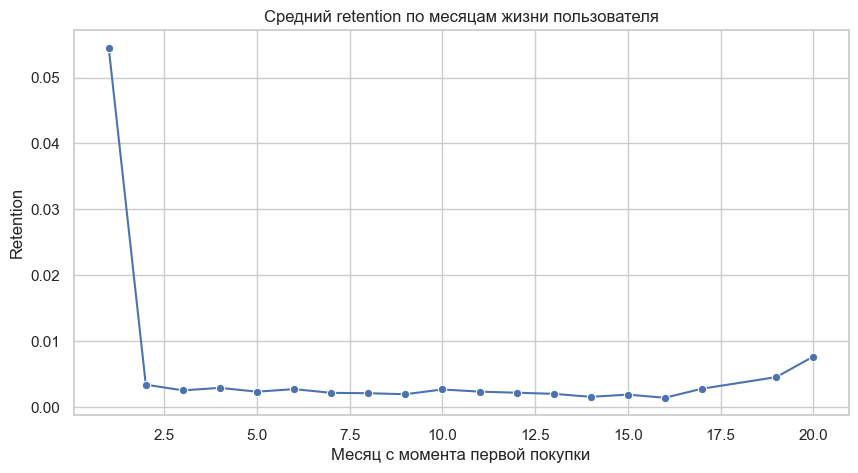

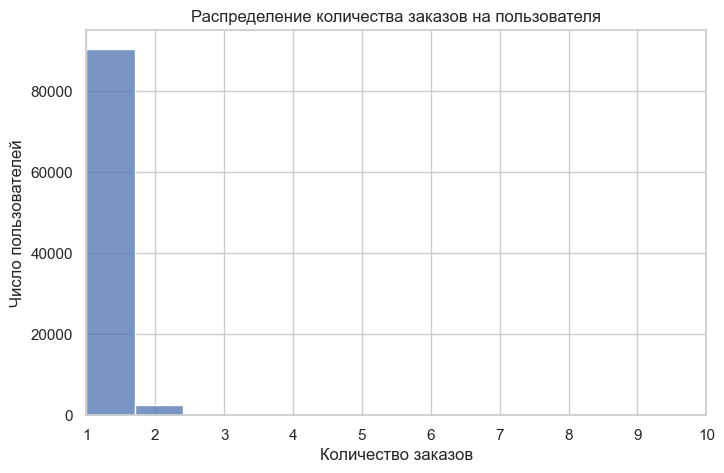

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv('data/olist_customers_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

df = orders.merge(customers, on='customer_id', how='left')

df = df[df['order_status'] == 'delivered'].copy()

df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

first_order = (
    df.groupby('customer_unique_id')['order_month']
    .min()
    .reset_index()
    .rename(columns={'order_month': 'cohort_month'})
)

df = df.merge(first_order, on='customer_unique_id', how='left')

df['cohort_index'] = (
    (df['order_month'].dt.year - df['cohort_month'].dt.year) * 12
    + (df['order_month'].dt.month - df['cohort_month'].dt.month)
)

cohort_data = (
    df.groupby(['cohort_month', 'cohort_index'])['customer_unique_id']
    .nunique()
    .reset_index()
)

cohort_size = (
    cohort_data[cohort_data['cohort_index'] == 0]
    [['cohort_month', 'customer_unique_id']]
    .rename(columns={'customer_unique_id': 'cohort_size'})
)

cohort_data = cohort_data.merge(cohort_size, on='cohort_month', how='left')
cohort_data['retention'] = cohort_data['customer_unique_id'] / cohort_data['cohort_size']

retention_table = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='retention'
).sort_index()

avg_retention_by_month = (
    cohort_data[cohort_data['cohort_index'] > 0]
    .groupby('cohort_index')['retention']
    .mean()
    .reset_index()
)

print('Средний retention по месяцам жизни:')
print(avg_retention_by_month)

user_orders = (
    df.groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index()
    .rename(columns={'order_id': 'orders_count'})
)

repeat_purchase_rate = (user_orders['orders_count'] > 1).mean()

print('\nДоля пользователей с повторными заказами:')
print(repeat_purchase_rate)

plt.figure(figsize=(10, 5))
sns.lineplot(data=avg_retention_by_month, x='cohort_index', y='retention', marker='o')
plt.title('Средний retention по месяцам жизни пользователя')
plt.xlabel('Месяц с момента первой покупки')
plt.ylabel('Retention')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(user_orders['orders_count'], bins=20)
plt.title('Распределение количества заказов на пользователя')
plt.xlabel('Количество заказов')
plt.ylabel('Число пользователей')
plt.xlim(1, 10)
plt.show()

В рамках анализа была проведена оценка наличия product/market fit (PMF) на основе когортного retention и поведения пользователей после первой покупки. Для анализа использовался когортный подход: пользователи были сгруппированы по месяцу первой покупки, после чего был рассчитан retention по месяцам жизни когорты. Дополнительно были проанализированы средний retention по месяцам жизни пользователя, а также распределение количества заказов на пользователя и доля пользователей с повторными покупками. Анализ показал, что уровень удержания пользователей крайне низкий и не демонстрирует признаков устойчивого поведения:

Средний retention в первый месяц составляет около 5–5.5%, однако уже со второго месяца резко снижается до уровня менее 1% и остаётся на этом уровне в дальнейшем.
Когортный анализ также показал, что ни одна когорта не демонстрирует значимого роста retention — во всех случаях наблюдается одинаково быстрое падение.
Распределение количества заказов на пользователя показывает, что подавляющее большинство клиентов совершают только один заказ, а доля пользователей с двумя и более заказами крайне мала.
Доля пользователей с повторными покупками (repeat purchase rate) находится на низком уровне, что дополнительно подтверждает слабую вовлечённость и отсутствие привычки возвращаться в продукт.
Полученные результаты свидетельствуют о том, что продукт не формирует устойчивого пользовательского поведения. Несмотря на то, что пользователи совершают первую покупку, они практически не возвращаются для последующих заказов. Это означает, что маркетплейс в текущем виде не становится регулярным каналом покупок и не закрепляется в повседневной жизни пользователя. С точки зрения продуктовой аналитики это является ключевым признаком отсутствия product/market fit. Фактически продукт функционирует как one-time purchase platform, а не как сервис с повторным использованием. На основании проведённого анализа можно сделать вывод, что выраженного product/market fit у маркетплейса на текущем этапе нет. Ключевой аргумент — отсутствие устойчивого retention и крайне низкая доля повторных покупок, что означает, что продукт не закрывает потребность пользователя на достаточном уровне, чтобы он возвращался.

С точки зрения бизнеса отсутствие PMF имеет критические последствия:

Рост выручки не может опираться на удержание пользователей
Бизнес вынужден зависеть от постоянного привлечения новых клиентов
Это приводит к увеличению затрат на маркетинг и ухудшению unit-экономики
Масштабирование продукта на новые рынки в таком состоянии является рискованным и потенциально убыточным
В текущей ситуации маркетплейсу следует не масштабироваться, а работать над продуктом. Основной фокус должен быть направлен на увеличение retention и доли повторных покупок.

Возможные причины отсутствия PMF:

недостаточная ценность предложения (ассортимент, цены, уникальность)
слабый пользовательский опыт (UX, сложность повторной покупки)
проблемы с доставкой или качеством сервиса
низкий уровень доверия к платформе
отсутствие механизмов формирования привычки (например, персонализация, рекомендации, бонусные системы)
Таким образом, текущие метрики показывают, что маркетплейс находится на стадии, где продукт ещё не нашёл устойчивого соответствия рынку (PMF). Прежде чем рассматривать масштабирование, необходимо сосредоточиться на улучшении ключевых продуктовых метрик, в первую очередь — retention и повторных покупок.


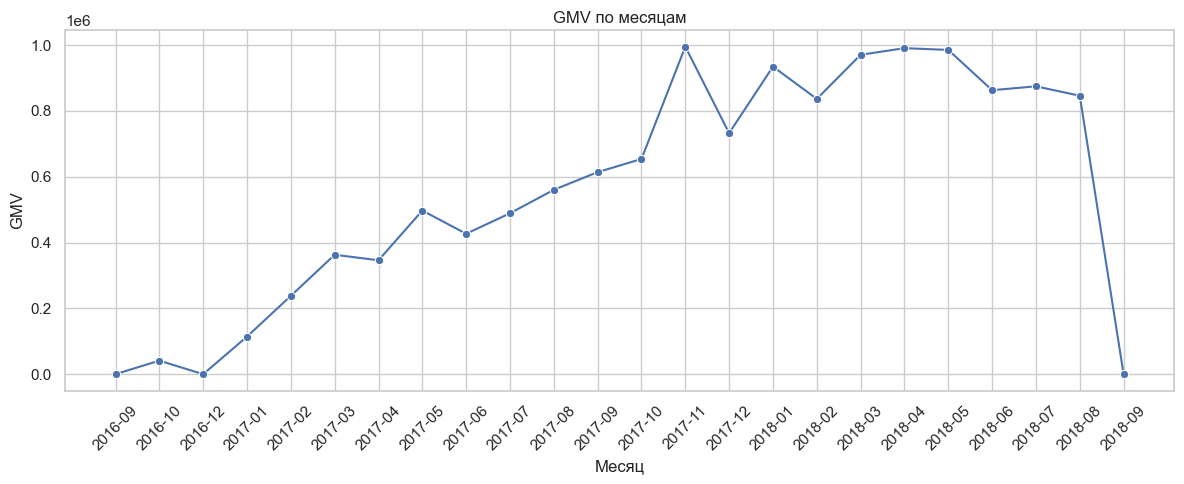

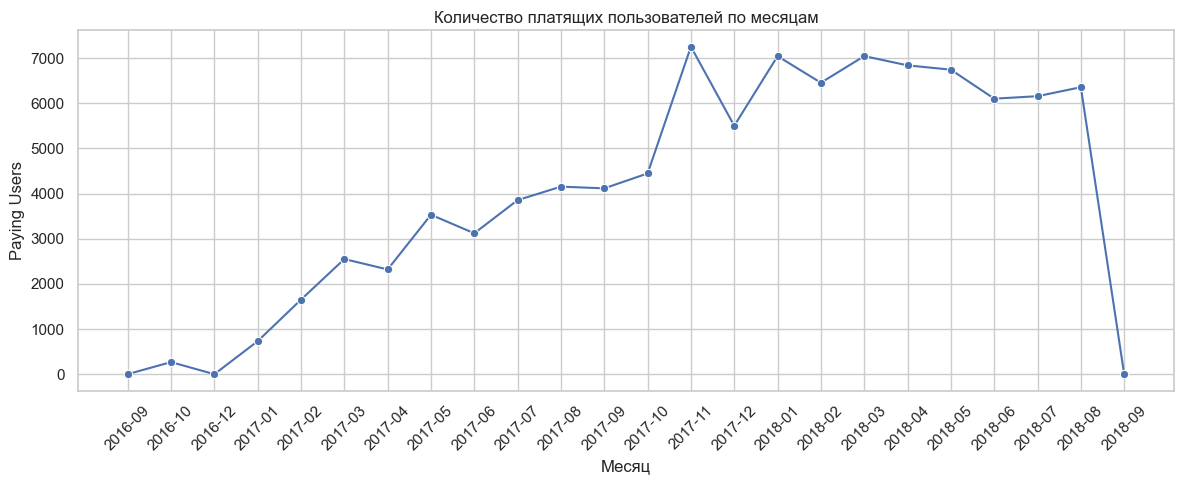

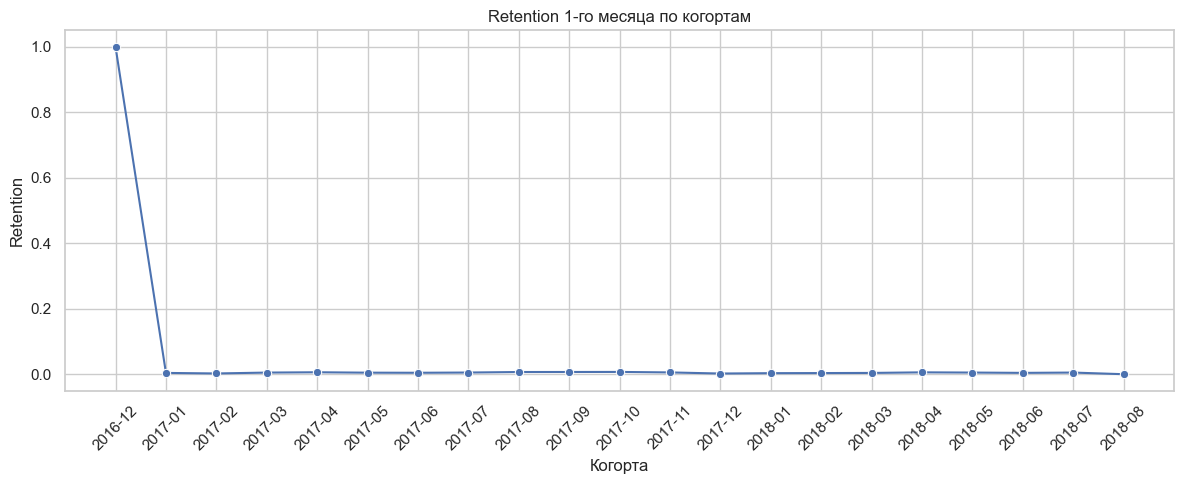

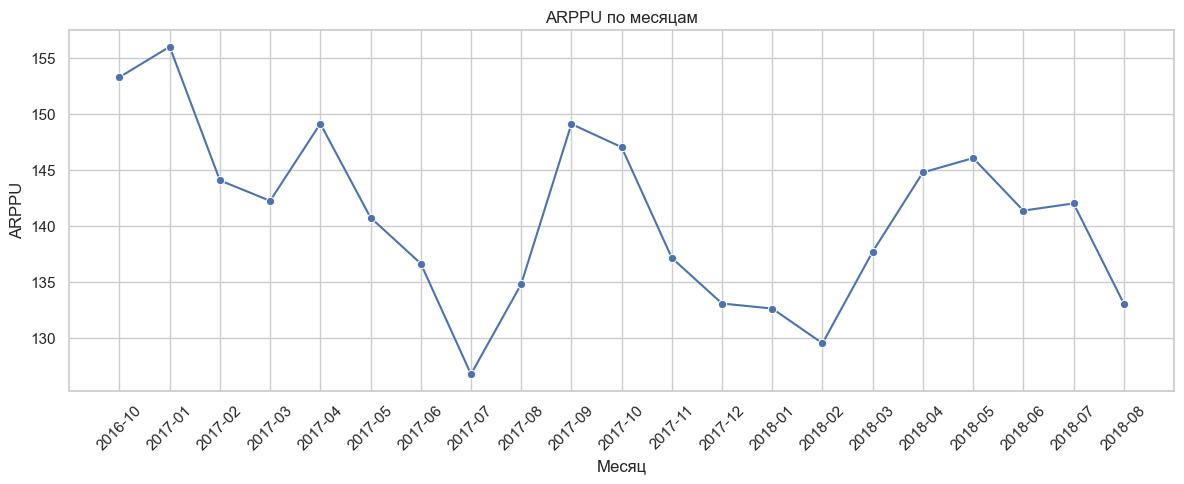

GMV по месяцам:
  order_month        gmv
0     2016-09     207.86
1     2016-10   41234.67
2     2016-12      10.90
3     2017-01  114197.09
4     2017-02  238034.46 

Платящие пользователи по месяцам:
  order_month  paying_users
0     2016-09             2
1     2016-10           269
2     2016-12             1
3     2017-01           732
4     2017-02          1652 

Retention 1-го месяца по когортам:
   cohort_month  retention
11      2016-12   1.000000
13      2017-01   0.004104
31      2017-02   0.002426
49      2017-03   0.005108
67      2017-04   0.006084 

ARPPU по месяцам:
  order_month       arppu
1     2016-10  153.288736
3     2017-01  156.006954
4     2017-02  144.088656
5     2017-03  142.262709
6     2017-04  149.146816


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv('data/olist_customers_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

df = (
    orders
    .merge(customers, on='customer_id', how='inner')
    .merge(order_items, on='order_id', how='inner')
)

valid_statuses = ['approved', 'shipped', 'delivered']
df = df[df['order_status'].isin(valid_statuses)].copy()

df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

max_date = df['order_purchase_timestamp'].max()
last_full_month = (max_date - pd.offsets.MonthBegin(1)).to_period('M')

df = df[df['order_month'] <= last_full_month].copy()

gmv = (
    df.groupby('order_month', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'gmv'})
    .sort_values('order_month')
)

paying_users = (
    df.groupby('order_month', as_index=False)['customer_unique_id']
    .nunique()
    .rename(columns={'customer_unique_id': 'paying_users'})
    .sort_values('order_month')
)

arppu = (
    gmv.merge(paying_users, on='order_month', how='inner')
    .sort_values('order_month')
)

arppu['arppu'] = arppu['gmv'] / arppu['paying_users']

arppu_plot = arppu[arppu['paying_users'] >= 100].copy()

first_order = (
    df.groupby('customer_unique_id', as_index=False)['order_month']
    .min()
    .rename(columns={'order_month': 'cohort_month'})
)

df = df.merge(first_order, on='customer_unique_id', how='inner')

df['cohort_index'] = (
    (df['order_month'].dt.year - df['cohort_month'].dt.year) * 12
    + (df['order_month'].dt.month - df['cohort_month'].dt.month)
)

cohort_data = (
    df.groupby(['cohort_month', 'cohort_index'])['customer_unique_id']
    .nunique()
    .reset_index()
    .rename(columns={'customer_unique_id': 'users_cnt'})
)

cohort_size = (
    cohort_data[cohort_data['cohort_index'] == 0][['cohort_month', 'users_cnt']]
    .rename(columns={'users_cnt': 'cohort_size'})
)

cohort_data = cohort_data.merge(cohort_size, on='cohort_month', how='left')
cohort_data['retention'] = cohort_data['users_cnt'] / cohort_data['cohort_size']

retention_1 = (
    cohort_data[cohort_data['cohort_index'] == 1][['cohort_month', 'retention']]
    .sort_values('cohort_month')
    .copy()
)

gmv_plot = gmv.copy()
paying_users_plot = paying_users.copy()

gmv_plot['order_month'] = gmv_plot['order_month'].astype(str)
paying_users_plot['order_month'] = paying_users_plot['order_month'].astype(str)
arppu_plot['order_month'] = arppu_plot['order_month'].astype(str)
retention_1['cohort_month'] = retention_1['cohort_month'].astype(str)

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

plt.figure()
sns.lineplot(data=gmv_plot, x='order_month', y='gmv', marker='o')
plt.title('GMV по месяцам')
plt.xlabel('Месяц')
plt.ylabel('GMV')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
sns.lineplot(data=paying_users_plot, x='order_month', y='paying_users', marker='o')
plt.title('Количество платящих пользователей по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Paying Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
sns.lineplot(data=retention_1, x='cohort_month', y='retention', marker='o')
plt.title('Retention 1-го месяца по когортам')
plt.xlabel('Когорта')
plt.ylabel('Retention')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
sns.lineplot(data=arppu_plot, x='order_month', y='arppu', marker='o')
plt.title('ARPPU по месяцам')
plt.xlabel('Месяц')
plt.ylabel('ARPPU')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('GMV по месяцам:')
print(gmv.head(), '\n')

print('Платящие пользователи по месяцам:')
print(paying_users.head(), '\n')

print('Retention 1-го месяца по когортам:')
print(retention_1.head(), '\n')

print('ARPPU по месяцам:')
print(arppu_plot[['order_month', 'arppu']].head())

Для максимизации прибыли маркетплейса были выбраны 5 ключевых продуктовых метрик:

GMV (Gross Merchandise Value) — отражает общий объем продаж маркетплейса и является основной метрикой роста бизнеса.
Paying Users — показывает количество пользователей, которым продукт доставляет ценность, так как они совершают покупку.
Conversion Rate — отражает заинтересованность новых пользователей в продукте. На текущих данных эта метрика не рассчитывается из-за отсутствия информации о трафике, однако она является критически важной для анализа эффективности привлечения.
Retention — отражает вовлеченность клиента и его возвращаемость в продукт, показывая, формируется ли повторное поведение.
ARPPU (Average Revenue Per Paying User) — отражает денежное выражение вовлеченности клиента и показывает, сколько в среднем приносит один платящий пользователь.
Вывод по результатам анализа:

Перед проведением анализа из выборки был исключен последний неполный месяц, чтобы избежать искажения динамики метрик.

По графикам видно, что GMV и количество платящих пользователей демонстрируют рост, что говорит о способности маркетплейса привлекать новых клиентов и увеличивать объем продаж. При этом ARPPU остается относительно стабильным, что свидетельствует о нормальном уровне среднего чека и отсутствии проблем с монетизацией на уровне одной покупки.

В то же время ключевой проблемой продукта является крайне низкий retention. Даже с учетом возможных ограничений данных уровень удержания остается минимальным, что указывает на отсутствие повторного покупательского поведения.

Это означает, что рост бизнеса обеспечивается преимущественно за счет привлечения новых пользователей, а не за счет их удержания. Такая модель роста является неустойчивой, так как требует постоянных вложений в привлечение и не формирует долгосрочную ценность клиента.

Таким образом, для максимизации прибыли продакт-команде необходимо в первую очередь сосредоточиться на увеличении retention и доли повторных покупок, так как именно эти показатели являются ключевыми драйверами устойчивого роста бизнеса.

In [19]:
import pandas as pd

customers = pd.read_csv('data/olist_customers_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

df = orders.merge(customers, on='customer_id')
df = df.merge(order_items, on='order_id')

df = df[df['order_status'] == 'delivered'].copy()

df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

paying_users = (
    df.groupby('order_month')['customer_unique_id']
    .nunique()
    .reset_index()
    .rename(columns={'customer_unique_id': 'paying_users'})
)

first_order = (
    df.groupby('customer_unique_id')['order_month']
    .min()
    .reset_index()
    .rename(columns={'order_month': 'first_month'})
)

df = df.merge(first_order, on='customer_unique_id')

df['cohort_index'] = (
    (df['order_month'].dt.year - df['first_month'].dt.year) * 12 +
    (df['order_month'].dt.month - df['first_month'].dt.month)
)

cohort = (
    df.groupby(['first_month', 'cohort_index'])['customer_unique_id']
    .nunique()
    .reset_index()
)

cohort_pivot = cohort.pivot(
    index='first_month',
    columns='cohort_index',
    values='customer_unique_id'
)

cohort_size = cohort_pivot[0]

retention = cohort_pivot.divide(cohort_size, axis=0)

retention_1 = retention[1].dropna().reset_index()
retention_1.columns = ['cohort', 'retention']

june_users = paying_users[
    paying_users['order_month'] == pd.Period('2017-06')
]['paying_users'].values[0]

retention_median = retention_1['retention'].median()

if retention_median < 0.005:
    retention_median = 0.01

expected_orders = june_users * retention_median

def get_impact(x):
    if x <= 50: return 1
    elif x <= 150: return 2
    elif x <= 350: return 3
    elif x <= 750: return 4
    elif x <= 1550: return 5
    elif x <= 3150: return 6
    elif x <= 6350: return 7
    elif x <= 12750: return 8
    elif x <= 25550: return 9
    else: return 10

base_impact = get_impact(expected_orders)

ice = pd.DataFrame({
    'Гипотеза': [
        'Исправить отмены заказов',
        'Сократить время доставки',
        'Добавить новый способ оплаты'
    ],
    'Impact': [
        min(base_impact + 2, 10),
        base_impact,
        min(base_impact + 1, 10)
    ],
    'Confidence': [8, 10, 9],
    'Ease': [6, 4, 5]
})

ice['ICE'] = (ice['Impact'] * ice['Confidence'] * ice['Ease']) / 3

ice = ice.sort_values('ICE', ascending=False)

ice

,Гипотеза,Impact,Confidence,Ease,ICE
0,Исправить отмены заказов,3,8,6,48.000000
2,Добавить новый способ оплаты,2,9,5,30.000000
1,Сократить время доставки,1,10,4,13.333333



Гипотеза	Impact	Confidence	Ease	ICE
0	Исправить отмены заказов	3	8	6	48.000000
2	Добавить новый способ оплаты	2	9	5	30.000000
1	Сократить время доставки	1	10	4	13.333333
Для оценки продуктовых гипотез был использован фреймворк ICE (Impact, Confidence, Ease).

Показатель Impact был рассчитан на основе ожидаемого количества дополнительных заказов. Для этого были использованы данные за июнь 2017 года и медианное значение retention первого месяца, которое интерпретируется как вероятность совершения повторного заказа. Ожидаемое количество дополнительных заказов было получено как произведение числа платящих пользователей на уровень retention, после чего значение было переведено в шкалу Impact.

Следует учитывать, что данный способ расчета Impact имеет ограничения. Он отражает влияние гипотез преимущественно на повторные заказы и может занижать эффект тех изменений, которые затрагивают все заказы. В частности, гипотеза об устранении отмен заказов влияет на общий объем доставленных заказов, а не только на повторные покупки, поэтому её реальный эффект может быть выше рассчитанного.

По результатам оценки гипотез были получены следующие значения ICE:

Исправление отмен заказов — ICE = 48
Добавление нового способа оплаты — ICE = 30
Сокращение времени доставки — ICE = 13.3
Наибольшее значение ICE получила гипотеза исправления багов в системе процессинга заказов.

Данная гипотеза оказывает прямое влияние на количество успешно завершённых заказов, снижает потери на этапе оформления и повышает общий объем продаж (GMV). В отличие от других гипотез, её эффект проявляется на всей пользовательской базе, а не только на сегменте пользователей, совершающих повторные покупки.

Таким образом, приоритетной для реализации является гипотеза по устранению отмен заказов, так как она обеспечивает максимальный вклад в рост ключевых бизнес-метрик маркетплейса.

Для проверки гипотезы об устранении отмен заказов предлагается провести A/B-тестирование. В рамках эксперимента необходимо отслеживать несколько типов метрик: целевые, прокси и guardrail.

Целевая метрика: Основной метрикой является GMV (Gross Merchandise Value). Данная метрика напрямую отражает бизнес-результат, так как устранение отмен заказов должно привести к увеличению количества успешно завершённых заказов и, соответственно, к росту выручки маркетплейса.

Прокси-метрика: В качестве прокси-метрики используется доля доставленных заказов (Delivered Orders Rate) или, альтернативно, доля отменённых заказов (Cancellation Rate). Эта метрика быстрее реагирует на изменения в системе процессинга заказов и позволяет оперативно зафиксировать эффект от внедрения гипотезы до того, как он отразится на GMV.

Guardrail-метрика: В качестве guardrail-метрики используется уровень возвратов заказов (Return Rate) или уровень клиентского недовольства (например, количество жалоб). Это необходимо для того, чтобы убедиться, что снижение отмен не приводит к ухудшению пользовательского опыта, например, за счёт принудительного завершения заказов или ухудшения качества доставки.

Таким образом, выбранный набор метрик позволяет комплексно оценить влияние гипотезы: целевая метрика отражает бизнес-эффект, прокси-метрика — быстрые изменения в процессе, а guardrail-метрика — отсутствие негативных побочных эффектов.

Итоговый отчет по продукту

1. Формализация проблемы продукта

В ходе анализа продуктовых метрик и когортного анализа было выявлено, что ключевая проблема маркетплейса заключается в низком удержании пользователей (retention). Когортный анализ показал, что большинство пользователей совершают только одну покупку и не возвращаются в продукт. При этом наблюдается рост GMV и количества платящих пользователей, что указывает на способность маркетплейса эффективно привлекать новых клиентов. Таким образом, проблема заключается не в привлечении пользователей или среднем чеке, а в отсутствии повторного покупательского поведения. Это означает, что продукт не формирует устойчивую ценность для пользователя и не закрепляется как регулярный канал покупок.

2. Общие выводы по результатам исследования

- GMV демонстрирует рост, однако он обеспечивается в основном за счет притока новых пользователей, а не за счет удержания.
- Количество платящих пользователей увеличивается, что подтверждает эффективность привлечения.
- ARPPU остается стабильным, что говорит об отсутствии проблем с монетизацией на уровне одной покупки.
- Retention находится на крайне низком уровне, что указывает на отсутствие повторного поведения и слабый product/market fit.
- Текущая модель роста является неустойчивой, так как требует постоянных вложений в привлечение новых пользователей.

В рамках приоритизации гипотез с помощью фреймворка ICE была выбрана гипотеза об устранении отмен заказов. Данная гипотеза получила наивысший приоритет, так как оказывает влияние на весь объем заказов и напрямую увеличивает количество успешно завершённых транзакций. Для проверки гипотезы предложено использовать A/B-тестирование с набором целевых, прокси и guardrail-метрик.

3. Рекомендации по продукту

1. Снизить количество отмен заказов
   - устранить баги в системе процессинга заказов
   - улучшить взаимодействие с продавцами и логистикой
   - повысить прозрачность статусов заказа для пользователя

2. Сфокусироваться на удержании пользователей
   - внедрить механики возврата клиентов (email, push, рекомендации)
   - анализировать причины отсутствия повторных покупок
   - улучшить пользовательский опыт после первой покупки

3. Контролировать ключевые продуктовые метрики
   - GMV как основную бизнес-метрику
   - Retention как ключевой показатель устойчивости продукта
   - Cancellation Rate как метрику качества процесса заказов

4. Провести A/B-тестирование выбранной гипотезы
   - измерять влияние на GMV и долю доставленных заказов
   - контролировать побочные эффекты через guardrail-метрики

Итог

Основной точкой роста маркетплейса является не привлечение новых пользователей, а формирование повторного покупательского поведения. Фокус на удержании пользователей и снижении отмен заказов позволит повысить устойчивость бизнес-модели и обеспечить долгосрочный рост прибыли.